In [3]:
!pip install openpyxl


In [17]:
import os
import json
import pandas as pd
from sklearn.model_selection import train_test_split

# =========================
# 1) Configuration
# =========================
FILE_PATH = r"C:\Users\hp\Downloads\SaudiBERT\complaints_clean_balanced_under.xlsx"
LABEL_COL = "الجهة"
TEXT_COL  = "clean_text"   # عدّلي لو اسم العمود مختلف
SAVE_DIR  = r"C:\Users\hp\Downloads\SaudiBERT\splits"

TEST_SIZE = 0.20
RANDOM_STATE = 42

# =========================
# 2) Load dataset
# =========================
df = pd.read_excel(FILE_PATH)

# Keep only rows with valid label + valid text
df = df.dropna(subset=[LABEL_COL, TEXT_COL]).copy()

# =========================
# 3) Stable numeric labels (FIXED mapping)
#    بدل factorize (قد يتغير حسب ترتيب البيانات)
# =========================
label_names = sorted(df[LABEL_COL].unique().tolist())  # ثابت 100%
label2id = {name: i for i, name in enumerate(label_names)}
id2label = {i: name for name, i in label2id.items()}

df["label"] = df[LABEL_COL].map(label2id).astype(int)

# =========================
# 4) Stratified train/validation split
# =========================
train_df, val_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

# =========================
# 5) Print summary
# =========================
print("\nSplit completed successfully.")
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Number of classes: {df['label'].nunique()}")

print("\nClass distribution in TRAIN:")
print(train_df[LABEL_COL].value_counts())

print("\nClass distribution in VALIDATION:")
print(val_df[LABEL_COL].value_counts())

# =========================
# 6) Save splits + mapping (Excel + JSON)
# =========================
os.makedirs(SAVE_DIR, exist_ok=True)

train_path = os.path.join(SAVE_DIR, "train_split.xlsx")
val_path   = os.path.join(SAVE_DIR, "val_split.xlsx")
map_xlsx   = os.path.join(SAVE_DIR, "label_mapping.xlsx")
map_json   = os.path.join(SAVE_DIR, "label_mapping.json")
cfg_json   = os.path.join(SAVE_DIR, "split_config.json")

train_df.to_excel(train_path, index=False)
val_df.to_excel(val_path, index=False)

label_map = pd.DataFrame({
    "label_id": list(id2label.keys()),
    "label_name": list(id2label.values())
})
label_map.to_excel(map_xlsx, index=False)

with open(map_json, "w", encoding="utf-8") as f:
    json.dump({"label2id": label2id, "id2label": id2label}, f, ensure_ascii=False, indent=2)

with open(cfg_json, "w", encoding="utf-8") as f:
    json.dump({
        "FILE_PATH": FILE_PATH,
        "LABEL_COL": LABEL_COL,
        "TEXT_COL": TEXT_COL,
        "TEST_SIZE": TEST_SIZE,
        "RANDOM_STATE": RANDOM_STATE
    }, f, ensure_ascii=False, indent=2)

print(f"\nSaved train split to: {train_path}")
print(f"Saved val split to:   {val_path}")
print(f"Saved label mapping to: {map_xlsx}")
print(f"Saved label mapping JSON to: {map_json}")
print(f"Saved split config to: {cfg_json}")


Split completed successfully.
Train size: 4544
Validation size: 1137
Number of classes: 13

Class distribution in TRAIN:
الجهة
وزارة التجارة                     350
الاحوال المدينة                   350
شركة الكهرباء السعودية            350
وزارة التعليم                     350
الجرائم المعلوماتية (كلنا أمن)    350
وزارة الرياضة                     350
الهيئة العامة للنقل               350
مكافحة مخدرات                     349
وزارة البيئة                      349
وزارة الصحة                       349
وزارة الحج والعمرة                349
شركة الاتصالات السعودية           349
بلدي                              349
Name: count, dtype: int64

Class distribution in VALIDATION:
الجهة
وزارة الصحة                       88
شركة الاتصالات السعودية           88
بلدي                              88
مكافحة مخدرات                     88
وزارة البيئة                      88
وزارة الحج والعمرة                88
شركة الكهرباء السعودية            87
وزارة التعليم                     87
الاحوال المدينة

In [19]:
import os, json
import pandas as pd

SAVE_DIR = r"C:\Users\hp\Downloads\SaudiBERT\splits"  # عدّلي لو تبين

# =========================
# 1) Build label vocabulary from TRAIN only (stable)
# =========================
unique_labels = sorted(train_df["الجهة"].dropna().unique().tolist())

label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print(f"Number of classes: {len(label2id)}")

# =========================
# 2) Encode train/val
# =========================
train_df = train_df.copy()
val_df   = val_df.copy()

train_df["label"] = train_df["الجهة"].map(label2id)
val_df["label"]   = val_df["الجهة"].map(label2id)

# =========================
# 3) Sanity check (STOP if val has unseen labels)
# =========================
nan_train = int(train_df["label"].isna().sum())
nan_val   = int(val_df["label"].isna().sum())

print(f"Missing labels in TRAIN (NaN): {nan_train}")
print(f"Missing labels in VALIDATION (NaN): {nan_val}")

if nan_train > 0:
    raise ValueError("TRAIN contains labels not in label2id. Check TRAIN 'الجهة' values.")

if nan_val > 0:
    unseen = sorted(val_df.loc[val_df["label"].isna(), "الجهة"].unique().tolist())
    raise ValueError(f"VALIDATION has unseen labels not in TRAIN mapping: {unseen}")

# Now safe to cast to int
train_df["label"] = train_df["label"].astype(int)
val_df["label"]   = val_df["label"].astype(int)

# =========================
# 4) Save mapping for future TEST (IMPORTANT)
# =========================
os.makedirs(SAVE_DIR, exist_ok=True)

# Excel mapping (nice for report)
label_map = pd.DataFrame({
    "label_id": list(id2label.keys()),
    "label_name": list(id2label.values())
})
label_map.to_excel(os.path.join(SAVE_DIR, "label_mapping.xlsx"), index=False)

# JSON mapping (best for code reuse)
with open(os.path.join(SAVE_DIR, "label_mapping.json"), "w", encoding="utf-8") as f:
    json.dump({"label2id": label2id, "id2label": id2label}, f, ensure_ascii=False, indent=2)

print("Saved label mapping (xlsx + json) to:", SAVE_DIR)

Number of classes: 13
Missing labels in TRAIN (NaN): 0
Missing labels in VALIDATION (NaN): 0
Saved label mapping (xlsx + json) to: C:\Users\hp\Downloads\SaudiBERT\splits


In [6]:
!pip install scikit-learn
!pip install datasets


In [20]:
from transformers import AutoConfig, AutoModelForSequenceClassification

# =========================
# 1) Model configuration
# =========================
model_name = "faisalq/SaudiBERT"

# Configure classification head
# - num_labels must match the number of classes
# - Dropout is increased (0.3) to reduce overfitting
# - label2id / id2label ensure consistent class mapping
config = AutoConfig.from_pretrained(
    model_name,
    num_labels=13,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3,
    label2id=label2id,
    id2label=id2label
)

# Load pre-trained SaudiBERT with classification head
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    config=config
)

# =========================
# 2) Layer freezing strategy
# =========================
# Freezing lower layers helps:
# - Preserve pre-trained linguistic knowledge
# - Reduce overfitting
# - Stabilize training on small/medium datasets

freeze_n_layers = 6  # Number of encoder layers to freeze

# Freeze embedding layer
for param in model.bert.embeddings.parameters():
    param.requires_grad = False

# Freeze first N encoder layers
for layer in model.bert.encoder.layer[:freeze_n_layers]:
    for param in layer.parameters():
        param.requires_grad = False

print(f"Embedding layer frozen: True")
print(f"Number of frozen encoder layers: {freeze_n_layers}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 739.70it/s, Materializing param=bert.encoder.layer.11.output.dense.weight]              
BertForSequenceClassification LOAD REPORT from: faisalq/SaudiBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those pa

Embedding layer frozen: True
Number of frozen encoder layers: 6


In [21]:
from transformers import AutoTokenizer
from datasets import Dataset

model_name = "faisalq/SaudiBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_ds = Dataset.from_pandas(train_df[["clean_text", "label"]], preserve_index=False)
val_ds   = Dataset.from_pandas(val_df[["clean_text", "label"]], preserve_index=False)

def tokenize(batch):
    return tokenizer(
        batch["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)

train_ds = train_ds.remove_columns(["clean_text"])
val_ds   = val_ds.remove_columns(["clean_text"])

train_ds = train_ds.rename_column("label", "labels")
val_ds   = val_ds.rename_column("label", "labels")

train_ds.set_format("torch")
val_ds.set_format("torch")

print("Tokenization completed successfully.")
print("Training dataset size:", len(train_ds))
print("Validation dataset size:", len(val_ds))

Map: 100%|██████████| 1137/1137 [00:00<00:00, 12673.60 examples/s]

Tokenization completed successfully.
Training dataset size: 4544
Validation dataset size: 1137


In [22]:
import os
import json

# =========================
# 1) Define save directory
# =========================
SAVE_PATH = r"C:\Users\hp\Downloads\SaudiBERT\tokenized_dataset"
os.makedirs(SAVE_PATH, exist_ok=True)

# =========================
# 2) Save tokenized datasets
# =========================
train_ds.save_to_disk(os.path.join(SAVE_PATH, "train"))
val_ds.save_to_disk(os.path.join(SAVE_PATH, "val"))

print("Tokenized datasets saved successfully.")
print(f"Location: {SAVE_PATH}")

# =========================
# 3) Save preprocessing metadata (VERY IMPORTANT)
# =========================
meta = {
    "model_name": "faisalq/SaudiBERT",
    "max_length": 256,
    "padding": "max_length",
    "truncation": True,
    "text_column": "clean_text",
    "label_column": "labels"
}

with open(os.path.join(SAVE_PATH, "preprocessing_config.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Saved preprocessing config.")

Saving the dataset (0/1 shards):   0%|          | 0/4544 [00:00<?, ? examples/s]

Saving the dataset (1/1 shards): 100%|██████████| 1137/1137 [00:00<00:00, 60393.64 examples/s]

Tokenized datasets saved successfully.
Location: C:\Users\hp\Downloads\SaudiBERT\tokenized_dataset
Saved preprocessing config.


In [23]:
import numpy as np
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.metrics import f1_score, accuracy_score
BEST_DIR   = r"C:\Users\hp\Downloads\SaudiBERT\final_model"   # هنا نحفظ الأفضل النهائي

# =========================
# 1) Evaluation Metrics
# =========================
# - Accuracy: overall correctness
# - F1-macro: treats all classes equally (important for imbalance)
# - F1-weighted: accounts for class frequency
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

# =========================
# 2) Training Configuration
# =========================
training_args = TrainingArguments(
    output_dir="saudibert_balanced_v1",
    eval_strategy="epoch",      # Evaluate at the end of each epoch
    save_strategy="epoch",            # Save checkpoint each epoch
    learning_rate=2e-5,               # Standard fine-tuning learning rate for BERT
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=15,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro", # Select best model based on macro-F1
    greater_is_better=True,
    fp16=True,                        # Mixed precision training (if GPU supports it)
    logging_steps=10,
    save_total_limit=2,               # Keep only last 2 checkpoints
    report_to="none"
)

# =========================
# 3) Trainer Initialization
# =========================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# =========================
# 4) Start Training
# =========================
trainer.train()


trainer.save_model(BEST_DIR)   


tokenizer.save_pretrained(BEST_DIR)

import json
with open(os.path.join(BEST_DIR, "label_mapping.json"), "w", encoding="utf-8") as f:
    json.dump({"label2id": label2id, "id2label": {str(k): v for k, v in id2label.items()}},
              f, ensure_ascii=False, indent=2)

print(" Saved BEST model + tokenizer + label mapping to:", BEST_DIR)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.669210,0.389348,0.894459,0.893410,0.893313
2,0.390375,0.203444,0.942832,0.942638,0.942597
3,0.174248,0.152420,0.953386,0.953276,0.953249
4,0.167896,0.140508,0.960422,0.960082,0.960020
5,0.092594,0.125293,0.963940,0.963828,0.963774
6,0.037385,0.109697,0.969217,0.969020,0.968978
7,0.026898,0.104054,0.970976,0.970846,0.970821
8,0.055995,0.111493,0.969217,0.969069,0.969029
9,0.009543,0.110025,0.973615,0.973385,0.973326
10,0.020206,0.113838,0.971856,0.971684,0.971623


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.60it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

✅ Saved BEST model + tokenizer + label mapping to: C:\Users\hp\Downloads\SaudiBERT\final_model


In [11]:
!pip install arabic-reshaper python-bidi tabulate

c:\Users\hp\Downloads\SaudiBERT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 700.49it/s, Materializing param=classifier.weight]                                      


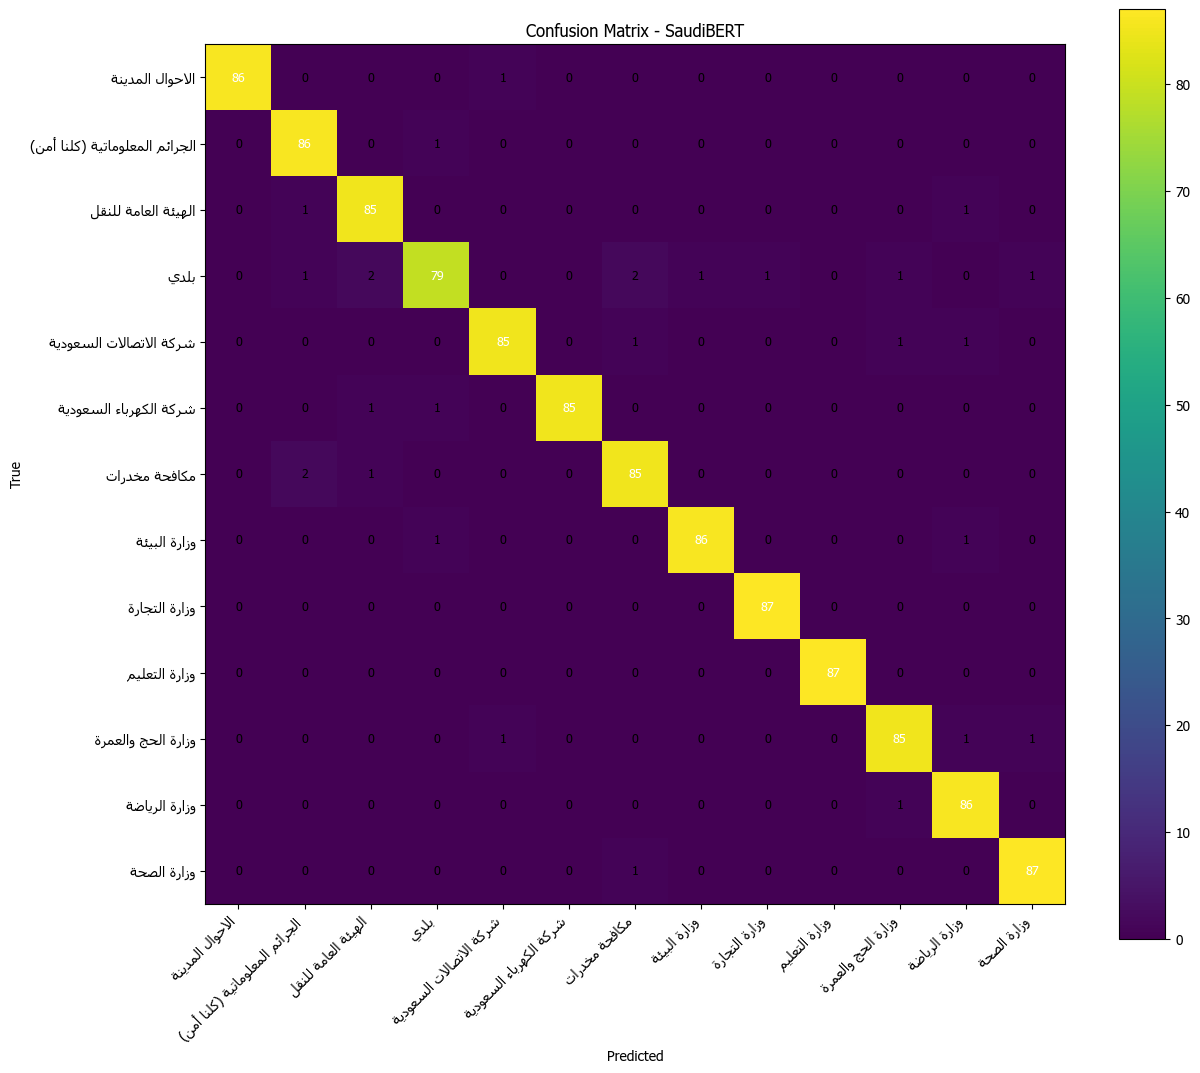


Classification Report (Validation):



,precision,recall,f1-score,support
الاحوال المدينة,1.000,0.989,0.994,87
الجرائم المعلوماتية (كلنا أمن),0.956,0.989,0.972,87
الهيئة العامة للنقل,0.955,0.977,0.966,87
بلدي,0.963,0.898,0.929,88
شركة الاتصالات السعودية,0.977,0.966,0.971,88
شركة الكهرباء السعودية,1.000,0.977,0.988,87
مكافحة مخدرات,0.955,0.966,0.960,88
وزارة البيئة,0.989,0.977,0.983,88
وزارة التجارة,0.989,1.000,0.994,87
وزارة التعليم,1.000,1.000,1.000,87


In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_from_disk
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer
from sklearn.metrics import confusion_matrix, classification_report

import arabic_reshaper
from bidi.algorithm import get_display

# =========================
# 0) Paths (EDIT IF NEEDED)
# =========================
MODEL_DIR = r"C:\Users\hp\Downloads\SaudiBERT\final_model"
VAL_DS_DIR = r"C:\Users\hp\Downloads\SaudiBERT\tokenized_dataset\val"

# =========================
# 1) Arabic rendering helper
# =========================
def ar(text: str) -> str:
    if not isinstance(text, str):
        text = str(text)
    return get_display(arabic_reshaper.reshape(text))

plt.rcParams["font.family"] = "Tahoma"
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 2) Load model + tokenizer + dataset (NO TRAINING)
# =========================
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
trainer = Trainer(model=model)

val_ds = load_from_disk(VAL_DS_DIR)

# =========================
# 3) Labels from config (or mapping file)
# =========================
id2label = model.config.id2label
labels = [id2label[i] for i in range(len(id2label))]
labels_ar = [ar(lbl) for lbl in labels]

# =========================
# 4) Predict
# =========================
pred = trainer.predict(val_ds)
y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=1)

# =========================
# 5) Confusion Matrix
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(13, 11))
plt.imshow(cm, interpolation="nearest")
plt.title(ar("Confusion Matrix - SaudiBERT"))
plt.colorbar()

tick_marks = np.arange(len(labels_ar))
plt.xticks(tick_marks, labels_ar, rotation=45, ha="right")
plt.yticks(tick_marks, labels_ar)

plt.xlabel(ar("Predicted"))
plt.ylabel(ar("True"))

thresh = cm.max() / 2.0 if cm.max() != 0 else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=9
        )

plt.tight_layout()
plt.show()

# =========================
# 6) Classification Report (table)
# =========================
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=labels,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T
report_df = report_df[["precision", "recall", "f1-score", "support"]]
report_df[["precision", "recall", "f1-score"]] = report_df[["precision", "recall", "f1-score"]].round(3)
report_df["support"] = report_df["support"].astype(int)

print("\nClassification Report (Validation):\n")
display(report_df)

In [2]:
import os, json, re
import numpy as np
import pandas as pd
from datasets import load_from_disk
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer

# ===============================
# 0) PATHS
# ===============================
MODEL_DIR   = r"C:\Users\hp\Downloads\SaudiBERT\final_model"
VAL_DS_DIR  = r"C:\Users\hp\Downloads\SaudiBERT\tokenized_dataset\val"
VAL_XLSX    = r"C:\Users\hp\Downloads\SaudiBERT\splits\val_split.xlsx"  # val_df
MAP_JSON    = os.path.join(MODEL_DIR, "label_mapping.json")             # محفوظ مع المودل

# ===============================
# 1) Load model + tokenizer
# ===============================
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
trainer = Trainer(model=model)

# ===============================
# 2) Load val dataset (tokenized) + val_df
# ===============================
val_ds = load_from_disk(VAL_DS_DIR)
val_df = pd.read_excel(VAL_XLSX)

# ===============================
# 3) Load id2label (SAFE)
# ===============================
if os.path.exists(MAP_JSON):
    with open(MAP_JSON, "r", encoding="utf-8") as f:
        m = json.load(f)
    id2label = {int(k): v for k, v in m["id2label"].items()}
else:
    # fallback from model config
    id2label = {int(k): v for k, v in model.config.id2label.items()}

# ===============================
# 4) Predict
# ===============================
pred = trainer.predict(val_ds)
y_pred = np.argmax(pred.predictions, axis=1)
predicted_labels = [id2label[i] for i in y_pred]

val_results = val_df.copy()
val_results["predicted_label"] = predicted_labels

# ===============================
# 5) RULE-BASED PRIORITY
# ===============================
LIGHT_STEM_REPLACEMENTS = [
    (r"\b(انقطع(ت|وا|نا)?|منقطع(ه)?|مقطوع(ه)?|مفصول(ه)?|طافي(ه)?|طفت|طفى|طفا)\b", "انقطاع"),
    (r"\b(تعطل(ت|وا|نا)?|معطل(ه)?|خربان(ه)?|خربت|وقف(ت|وا|نا)?|متوقف(ه)?|مايشتغل|ما يشتغل)\b", "توقف"),
    (r"\b(يحترق|احترق(ت|وا|نا)?|احتراق|حريق|ولع(ت|وا|نا)?|مولع)\b", "حريق"),
    (r"\b(تسرب|يسرب|سرب(ت|وا|نا)?|تهريب)\b", "تسرب"),
    (r"\b(هدد(ني|نا|هم)?|تهديد|يتوعد|توعد)\b", "تهديد"),
    (r"\b(تحرش|يتحرش|تحرش(وا|ت)?|اعتدى|اعتداء|اعتدا(ت|وا)?)\b", "اعتداء"),
    (r"\b(تسمم|مسمم|تسممت|سم(م)?|سموم)\b", "تسمم"),
]

def light_stem(text: str) -> str:
    text = str(text)
    for pat, rep in LIGHT_STEM_REPLACEMENTS:
        text = re.sub(pat, rep, text)
    return text

GLOBAL_URGENT_PATTERNS = [
    r"(خطر|كارثة|طارئ|عاجل|فورا|الحين|الان|ضروري)",
    r"(حريق|انفجار|غرق)",
    r"(نزيف|فقدان وعي|اغماء|اختناق)",
    r"(تسمم)",
    r"(اعتداء|تحرش|تهديد|ابتزاز)",
    r"(محبوس|محتجز|عالق)",
    r"(حادث|اصابة|مصاب)",
    r"(انقطاع)",
    r"(تسرب)",
    r"(توقف)",
]

AUTHORITY_URGENT_PATTERNS = {
    "شركة الكهرباء السعودية": [
        r"(تماس كهربائي|سلك مكشوف|شرار|ماس)",
        r"(حريق)",
        r"(انقطاع)"
    ],
    "شركة الاتصالات السعودية": [
        r"(انقطاع)",
        r"(لا يوجد شبكة|مافي شبكة|بدون شبكة|ضعف شديد)",
        r"(توقف).*(انترنت|نت|خدمة)"
    ],
    "وزارة الصحة": [
        r"(حالة حرجة|حرجة|لا يوجد طبيب|لا يوجد اسعاف|رفض استقبال|خطأ طبي)",
        r"(نزيف|فقدان وعي|تسمم|اختناق)"
    ],
    "الجرائم المعلوماتية (كلنا أمن)": [
        r"(ابتزاز|تهديد|اختراق|هكر|تسريب|نشر صور|احتيال|نصب)"
    ],
    "مكافحة مخدرات": [
        r"(مخدرات|ترويج|حشيش|شبو|كبتاجون)"
    ],
    "بلدي": [
        r"(سقوط مبنى|خطر انهيار|انهيار)",
        r"(حفرة خطيرة|صرف مكشوف|فيض|تجمع مياه)"
    ],
    "وزارة التعليم": [
        r"(اعتداء|تحرش|تنمر شديد)",
        r"(خطر على الطلاب|مدرسة غير آمنة|اصابة طالب)"
    ],
    "وزارة الحج والعمرة": [
        r"(مفقود|ضايع|تائه)",
        r"(تدافع|ازدحام شديد|خطر)",
        r"(حادث|اصابة|مصاب)"
    ],
    "وزارة الرياضة": [
        r"(تدافع|ازدحام شديد|خطر)",
        r"(اعتداء|تحرش)",
        r"(حادث|اصابة|مصاب)"
    ],
    "وزارة التجارة": [
        r"(فاسد|منتهي الصلاحية|غش|مغشوش|تلاعب غذائي)",
        r"(تسمم)"
    ],
    "وزارة البيئة": [
        r"(تلوث|نفوق|روائح كريهة|تسرب نفطي|مخلفات خطرة)",
        r"(حريق)"
    ],
    "الهيئة العامة للنقل": [
        r"(حادث|اصابة|مصاب|اصطدم|دهس)",
        r"(سائق متهور|طريق غير آمن)"
    ],
    "الأحوال المدينة": [
        r"(وفاة|بلاغ وفاة)",
        r"(هوية).*(مفقود|ضايعة|مسروقة)"
    ],
}

def classify_priority_with_reason(text: str, authority: str):
    t = light_stem(text)

    # GLOBAL first
    for pat in GLOBAL_URGENT_PATTERNS:
        m = re.search(pat, t)
        if m:
            return "عاجله", f"GLOBAL: {m.group()}"

    # Authority-specific
    for pat in AUTHORITY_URGENT_PATTERNS.get(authority, []):
        m = re.search(pat, t)
        if m:
            return "عاجله", f"{authority}: {m.group()}"

    return "عاديه", ""

val_results[["priority", "priority_reason"]] = val_results.apply(
    lambda r: pd.Series(classify_priority_with_reason(r["clean_text"], r["predicted_label"])),
    axis=1
)

val_results[["clean_text", "الجهة", "predicted_label", "priority", "priority_reason"]].head(40)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 476.26it/s, Materializing param=classifier.weight]                                      


,clean_text,الجهة,predicted_label,priority,priority_reason
0,مستشفى جيزان العام يعاني من إهمال، وقسم الطوار...,وزارة الصحة,وزارة الصحة,عاديه,
1,السلام عليكم الكهرب طافي بغطي له ساعتين ونص عن...,شركة الكهرباء السعودية,شركة الكهرباء السعودية,عاجله,GLOBAL: انقطاع
2,والله لم اجد تجاوب منكم ولا معالجة لطلبي رغم س...,وزارة التعليم,وزارة التعليم,عاديه,
3,لاحظت انه ما في كافية عن المراكز اللي تعطي لقا...,وزارة الصحة,وزارة الصحة,عاديه,
4,لاحظت في مستشفى الملك سعود الطبي بالرياض انه ف...,وزارة الصحة,وزارة الصحة,عاديه,
5,السلام وعليكم ممكن تفيدونا ثلاثه اشهور اشحن با...,شركة الاتصالات السعودية,شركة الاتصالات السعودية,عاديه,
6,والله يا شيخ ابي احد يتصرف في مشكلتي، انا محاو...,وزارة الصحة,وزارة الصحة,عاديه,
7,أرجو الإفادة هل الحاضنه تستطيع تعديل أسماء الأ...,الاحوال المدينة,الاحوال المدينة,عاديه,
8,اشتريت عبايه من متجر معروف وبعد الدفع اكتشفت و...,وزارة التجارة,وزارة التجارة,عاجله,GLOBAL: عاجل
9,تنظيف الشارع من الاتربة ونشر الغبار على بيوت ف...,بلدي,بلدي,عاديه,


In [26]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = r"C:\Users\hp\Downloads\SaudiBERT\final_model"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(device)
model.eval()

print("Model loaded on:", device)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1052.38it/s, Materializing param=classifier.weight]                                     


Model loaded on: cuda


In [27]:
def predict(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    pred_id = torch.argmax(outputs.logits, dim=1).item()
    label = model.config.id2label[pred_id]

    priority, reason = classify_priority_with_reason(text, label)

    return {
        "predicted_label": label,
        "priority": priority,
        "priority_reason": reason
    }

In [28]:
while True:
    complaint = input("\nاكتب الشكوى (q للخروج): ")

    if complaint.lower() == "q":
        print("تم الخروج ")
        break

    prediction = predict(complaint)

    print("\n الشكوى:", complaint)
    print(" الجهة المتوقعة:", prediction)


 الشكوى: السلام عليكم،فيه منشأة رياضية قريبة من بيتنا فيها ملاعب وصالات، لكن الفترة الأخيرة صاير فيه إهمال واضح من ناحية الصيانة والتنظيم. الأرضيات متضررة والإنارة أحيانًا ما تشتغل كويس، وكثير من الناس اشتكوا بس ما فيه تجاوب. المكان مفروض يخدم الشباب والأنشطة، لكن الوضع الحالي ما يساعد. نأمل النظر في الموضوع وتحسين الإشراف والمتابعة.
 الجهة المتوقعة: {'predicted_label': 'بلدي', 'priority': 'عاديه', 'priority_reason': ''}

 الشكوى: فيه موقع بالحي متروك ومتجمع فيه مخلفات وصارت تطلع منه روائح وحشرات، والموضوع مسبب إزعاج للسكان. نأمل يتم التعامل معه بأسرع وقت.
 الجهة المتوقعة: {'predicted_label': 'بلدي', 'priority': 'عاديه', 'priority_reason': ''}

 الشكوى: نادي الحي اجهزته خايسه وخدماته مروحه 
 الجهة المتوقعة: {'predicted_label': 'وزارة الرياضة', 'priority': 'عاديه', 'priority_reason': ''}

 الشكوى: السلام عليكم،في تأخير واضح بتنظيم الفعاليات في أحد الأندية القريبة، والمستفيدين متضررين من سوء الإدارة. نأمل تحسين المتابعة
 الجهة المتوقعة: {'predicted_label': 'وزارة الرياضة', 'priority': '